In [1]:
# ============================
# F5 — Week 06: BO update (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================

# ----------------------------
# Imports (keep all at top)
# ----------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*lbfgs failed to converge.*")

In [2]:
# ----------------------------
# 0) Config
# ----------------------------
# Your project paths (as requested)
INPUTS_PATH = "data/F5/initial_inputs.npy"
OUTPUTS_PATH = "data/F5/initial_outputs.npy"

# Fallback to local uploaded paths (handy in Colab / sandbox)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Domain
BOUNDS = np.array([[0.0, 1.0]] * 4)

# Acquisition / sampling
RANDOM_SEED = 42
BATCH_SIZE = 1                  # tutor wants ONE row
N_CANDIDATES = 60000            # candidate pool size
LOCAL_FRAC = 0.90               # mostly local refinement
LOCAL_STD = 0.015               # tighter than last week (ultra-fine search)
KAPPA = 0.10                    # more exploitation than Week 04
MIN_DIST_TO_EXISTING = 0.010    # avoid resubmitting near-duplicates
# Secondary surrogates (for uncertainty cross-checks)
RF_N_ESTIMATORS = 600
RF_MIN_SAMPLES_LEAF = 2

GBM_ENSEMBLE_SIZE = 12
GBM_N_ESTIMATORS = 350
GBM_LEARNING_RATE = 0.05
GBM_MAX_DEPTH = 3
GBM_SUBSAMPLE = 0.8


In [3]:
# ----------------------------
# 1) Load
# ----------------------------
def resolve_path(primary: str, fallback: str) -> str:
    return primary if os.path.exists(primary) else fallback

X_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(X_path)
y = np.load(y_path)

assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (n,4). Got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,). Got {y.shape}"
assert np.all(X >= 0.0) and np.all(X <= 1.0), "Expected X within [0,1]^4"

n = X.shape[0]
print(f"Loaded F5 dataset: n={n} points, d={X.shape[1]} dims.")
print(f"y stats: min={y.min():.6g}, median={np.median(y):.6g}, max={y.max():.6g}")

# Transform (stabilise extreme range)
y_t = np.log1p(y)  # log(1+y)
best_idx = int(np.argmax(y))
print(f"Current best observed y: {y[best_idx]:.6g} at x={X[best_idx]}")


Loaded F5 dataset: n=25 points, d=4 dims.
y stats: min=0.11294, median=78.4344, max=4449.77
Current best observed y: 4449.77 at x=[0.212855 1.       1.       1.      ]


In [4]:
# ----------------------------
# 2) Surrogate (GP + ARD) + uncertainty cross-checks (RF, GBM ensemble)
# ----------------------------
# Primary surrogate: GP on transformed outputs (log1p)
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.ones(X.shape[1]),
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,            # nugget for numerical stability
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED
)
gp.fit(X, y_t)

print("\nTrained GP kernel:")
print(gp.kernel_)

# Extract ARD lengthscales (interpretability)
try:
    lengthscales = gp.kernel_.k2.length_scale
    print("\nARD lengthscales (smaller => more sensitive):", np.array2string(lengthscales, precision=4))
except Exception:
    lengthscales = None
    print("\nCould not extract ARD lengthscales from kernel.")

# Secondary surrogate 1: Random Forest (uncertainty via per-tree spread)
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X, y_t)

def rf_predict_mean_std(X_new: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Approximate epistemic uncertainty from ensemble spread
    tree_preds = np.stack([est.predict(X_new) for est in rf.estimators_], axis=0)
    return tree_preds.mean(axis=0), tree_preds.std(axis=0, ddof=1)

# Secondary surrogate 2: GBM ensemble (uncertainty via model-to-model spread)
gbm_ensemble = []
for i in range(GBM_ENSEMBLE_SIZE):
    gbm = GradientBoostingRegressor(
        n_estimators=GBM_N_ESTIMATORS,
        learning_rate=GBM_LEARNING_RATE,
        max_depth=GBM_MAX_DEPTH,
        subsample=GBM_SUBSAMPLE,
        random_state=RANDOM_SEED + 1000 + i
    )
    gbm.fit(X, y_t)
    gbm_ensemble.append(gbm)

def gbm_predict_mean_std(X_new: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    preds = np.stack([m.predict(X_new) for m in gbm_ensemble], axis=0)
    return preds.mean(axis=0), preds.std(axis=0, ddof=1)

print(f"\nFitted RF (n_estimators={RF_N_ESTIMATORS}) and GBM ensemble (size={GBM_ENSEMBLE_SIZE}).")



Trained GP kernel:
2.16**2 * Matern(length_scale=[2.41, 0.695, 1.38, 0.836], nu=2.5)

ARD lengthscales (smaller => more sensitive): [2.4084 0.6948 1.3833 0.8363]

Fitted RF (n_estimators=600) and GBM ensemble (size=12).


In [5]:
# ----------------------------
# 3) Acquisition (UCB) → pick ONE next X row
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

best_idx = int(np.argmax(y_t))
x_best = X[best_idx].copy()

n_local = int(N_CANDIDATES * LOCAL_FRAC)
n_global = N_CANDIDATES - n_local

# Local candidates: around current best
cand_local = x_best + rng.normal(0.0, LOCAL_STD, size=(n_local, X.shape[1]))
cand_local = np.clip(cand_local, BOUNDS[:, 0], BOUNDS[:, 1])

# Global candidates: uniform in domain (anti-premature-convergence guard)
cand_global = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(n_global, X.shape[1]))

CAND = np.vstack([cand_local, cand_global])

mu, std = gp.predict(CAND, return_std=True)          # in log1p space
ucb = mu + KAPPA * std

# Sort by acquisition value (descending)
order = np.argsort(-ucb)

def min_dist_to_set(x: np.ndarray, X_set: np.ndarray) -> float:
    # Euclidean distance to nearest point in X_set
    d = np.linalg.norm(X_set - x[None, :], axis=1)
    return float(d.min())

# Choose first high-UCB candidate not too close to existing points
x_next = None
for idx in order:
    x_cand = CAND[idx]
    if min_dist_to_set(x_cand, X) >= MIN_DIST_TO_EXISTING:
        x_next = x_cand
        break

# If everything was too close (rare), just take the top-UCB point
if x_next is None:
    x_next = CAND[order[0]]

X_next_batch = x_next.reshape(1, -1)

# Quick cross-check: predictions at the proposed point (log1p space)
gp_mu_next, gp_std_next = gp.predict(X_next_batch, return_std=True)
rf_mu_next, rf_std_next = rf_predict_mean_std(X_next_batch)
gbm_mu_next, gbm_std_next = gbm_predict_mean_std(X_next_batch)

print("\nPredictions at proposed x_next (log1p space):")
print(f" - GP : mean={gp_mu_next[0]:.6g}, std={gp_std_next[0]:.6g}")
print(f" - RF : mean={rf_mu_next[0]:.6g}, std={rf_std_next[0]:.6g}")
print(f" - GBM: mean={gbm_mu_next[0]:.6g}, std={gbm_std_next[0]:.6g}")



Predictions at proposed x_next (log1p space):
 - GP : mean=8.41196, std=0.0641586
 - RF : mean=7.88664, std=0.428934
 - GBM: mean=8.36514, std=0.066599



Diagnostics (train, log1p scale):
 - RMSE: 7.53615e-06
 - R2:   1
 - Residual mean: 9.79e-09, std: 7.69e-06


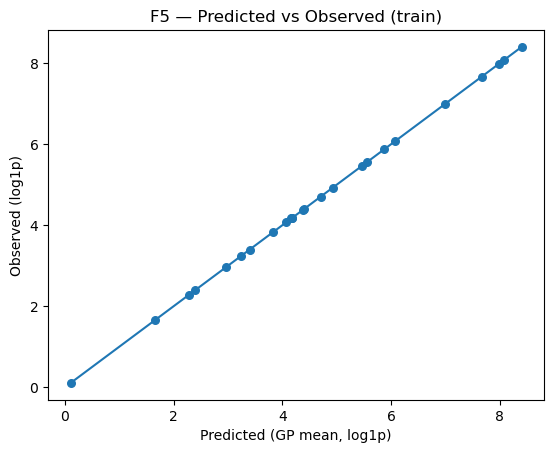

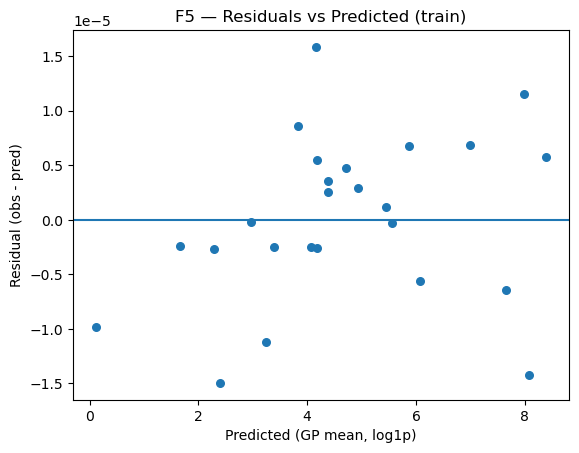

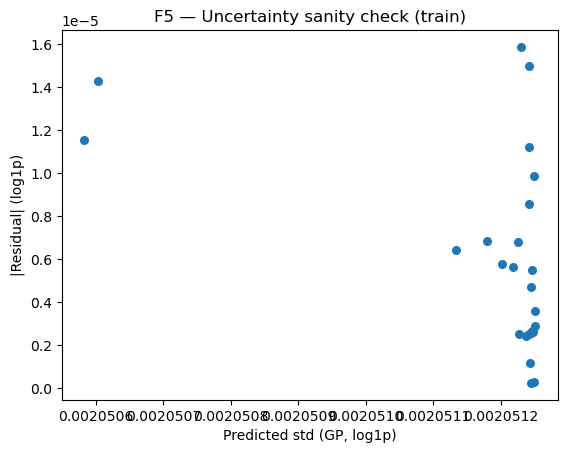


RF permutation importances (higher => more important):
 - x4: 1.16175
 - x3: 0.140183
 - x2: 0.123085
 - x1: 0.0262293


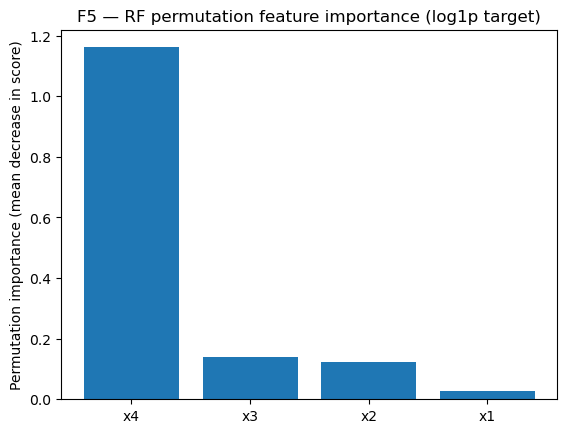


Proposed point min distance to existing samples: 0.0561292
Points within radius 0.03 of current best: 1 / 25


In [6]:
# ----------------------------
# 4) Diagnostics
# ----------------------------
# GP fit quality on training data (log1p scale)
mu_train, std_train = gp.predict(X, return_std=True)

rmse = np.sqrt(mean_squared_error(y_t, mu_train))
r2 = r2_score(y_t, mu_train)
resid = (y_t - mu_train)

print("\nDiagnostics (train, log1p scale):")
print(f" - RMSE: {rmse:.6g}")
print(f" - R2:   {r2:.6g}")
print(f" - Residual mean: {resid.mean():.3g}, std: {resid.std(ddof=1):.3g}")

# Predicted vs observed
plt.figure()
plt.scatter(mu_train, y_t, s=30)
lims = [min(mu_train.min(), y_t.min()), max(mu_train.max(), y_t.max())]
plt.plot(lims, lims)
plt.xlabel("Predicted (GP mean, log1p)")
plt.ylabel("Observed (log1p)")
plt.title("F5 — Predicted vs Observed (train)")
plt.show()

# Residuals
plt.figure()
plt.scatter(mu_train, resid, s=30)
plt.axhline(0.0)
plt.xlabel("Predicted (GP mean, log1p)")
plt.ylabel("Residual (obs - pred)")
plt.title("F5 — Residuals vs Predicted (train)")
plt.show()

# Uncertainty sanity check: |residual| vs predicted std
plt.figure()
plt.scatter(std_train, np.abs(resid), s=30)
plt.xlabel("Predicted std (GP, log1p)")
plt.ylabel("|Residual| (log1p)")
plt.title("F5 — Uncertainty sanity check (train)")
plt.show()

# Feature importance cross-check (RF permutation importance on log1p target)
perm = permutation_importance(rf, X, y_t, n_repeats=12, random_state=RANDOM_SEED, n_jobs=1)
imp_mean = perm.importances_mean
order = np.argsort(-imp_mean)

print("\nRF permutation importances (higher => more important):")
for j in order:
    print(f" - x{j+1}: {imp_mean[j]:.6g}")

plt.figure()
plt.bar([f"x{j+1}" for j in order], imp_mean[order])
plt.ylabel("Permutation importance (mean decrease in score)")
plt.title("F5 — RF permutation feature importance (log1p target)")
plt.show()

# Coverage check: distance of proposed point to nearest existing sample
def min_dist_to_set(x: np.ndarray, X_set: np.ndarray) -> float:
    d = np.linalg.norm(X_set - x[None, :], axis=1)
    return float(d.min())

d_next = min_dist_to_set(X_next_batch[0], X)
print(f"\nProposed point min distance to existing samples: {d_next:.6g}")

# Simple “not stuck” check: how many points are within a small ball around x_best?
best_idx = int(np.argmax(y))
x_best = X[best_idx]
ball_r = 0.03
near = np.linalg.norm(X - x_best[None, :], axis=1) <= ball_r
print(f"Points within radius {ball_r} of current best: {int(near.sum())} / {X.shape[0]}")


In [7]:
# ----------------------------
# 5) Output (submit ONE row)
# ----------------------------
np.set_printoptions(precision=6, suppress=True)

print("\nSuggested NEXT batch (shape (1,4)):")
print(X_next_batch)

print("\nSingle best NEXT point (submit this ONE line):")
print(X_next_batch[0])

# Context only (NOT for submission): predicted yield on original scale (approx)
gp_mu, gp_std = gp.predict(X_next_batch, return_std=True)

# Treat GP in log1p space as approximately Gaussian:
# median_y ≈ expm1(mu), mean_y ≈ expm1(mu + 0.5*std^2)
pred_median = np.expm1(gp_mu[0])
pred_mean = np.expm1(gp_mu[0] + 0.5 * (gp_std[0] ** 2))
pred_hi = np.expm1(gp_mu[0] + 1.96 * gp_std[0])
pred_lo = np.expm1(gp_mu[0] - 1.96 * gp_std[0])

print("\nGP prediction (original y scale, approximate):")
print(f" - median: {pred_median:.6g}")
print(f" - mean:   {pred_mean:.6g}")
print(f" - 95% CI: [{pred_lo:.6g}, {pred_hi:.6g}]")



Suggested NEXT batch (shape (1,4)):
[[0.156726 1.       1.       1.      ]]

Single best NEXT point (submit this ONE line):
[0.156726 1.       1.       1.      ]

GP prediction (original y scale, approximate):
 - median: 4499.56
 - mean:   4508.84
 - 95% CI: [3967.75, 5102.64]
